<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 24)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.00e-05 | train loss 1.3369 acc 0.510 | val loss 1.1996 acc 0.468 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.00e-05 | train loss 1.1072 acc 0.541 | val loss 0.9175 acc 0.542 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.00e-05 | train loss 0.8196 acc 0.643 | val loss 0.6417 acc 0.764 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.00e-05 | train loss 0.5815 acc 0.789 | val loss 0.5070 acc 0.818 *


...

[ConvNeXt-Tiny] Epoch  12/100 | LR: 5.00e-05 | train loss 0.0870 acc 0.957 | val loss 0.3542 acc 0.867


[ConvNeXt-Tiny] Epoch  13/100 | LR: 5.00e-05 | train loss 0.0562 acc 0.970 | val loss 0.3495 acc 0.887


[ConvNeXt-Tiny] Epoch  14/100 | LR: 5.00e-05 | train loss 0.0396 acc 0.981 | val loss 0.4848 acc 0.867


[ConvNeXt-Tiny] Epoch  15/100 | LR: 5.00e-06 | train loss 0.0920 acc 0.964 | val loss 0.4410 acc 0.882


[ConvNeXt-Tiny] Epoch  16/100 | LR: 5.00e-06 | train loss 0.0523 acc 0.973 | val loss 0.3988 acc 0.892

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 16.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3285)


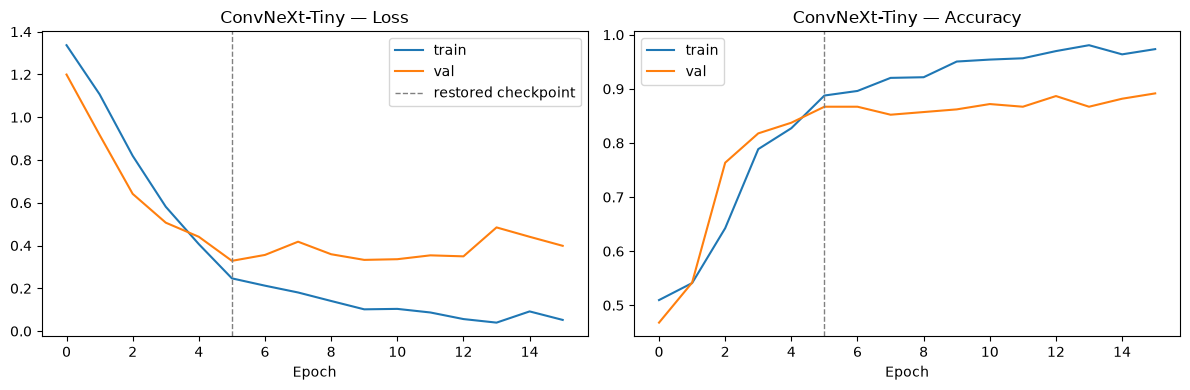

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.709


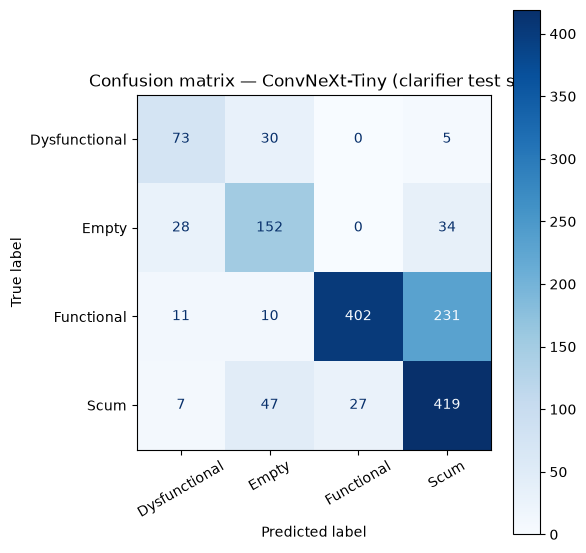

               precision    recall  f1-score   support

Dysfunctional      0.613     0.676     0.643       108
        Empty      0.636     0.710     0.671       214
   Functional      0.937     0.615     0.742       654
         Scum      0.608     0.838     0.705       500

     accuracy                          0.709      1476
    macro avg      0.699     0.710     0.690      1476
 weighted avg      0.758     0.709     0.712      1476



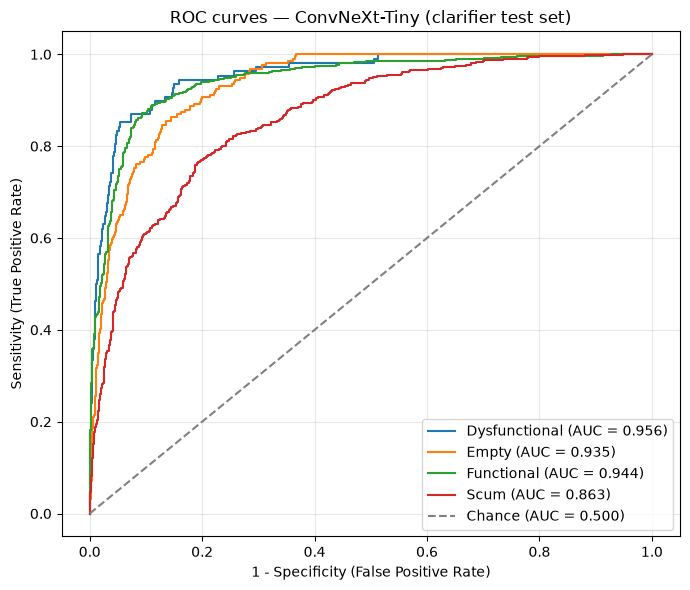

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.956
  Empty          : 0.935
  Functional     : 0.944
  Scum           : 0.863

Mean AUC (over 4/4 classes with test examples): 0.924


(np.float64(0.7086720867208672),
 {'Dysfunctional': 0.95586284383799,
  'Empty': 0.9348793637158048,
  'Functional': 0.9441803016436378,
  'Scum': 0.8626577868852459})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_CapeFlats.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
